**Импортируем необходимые библиотеки**

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from scipy.stats import chi2_contingency

**Загрузка данных**

In [2]:
train = pd.read_csv("../data/raw/train.csv")

## Обзор данных 

In [ ]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Количество объектов и признаков**

In [3]:
train.shape

(891, 12)

**Типы признаков и пропуски**

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


**Количество уникальных значений**

In [6]:
train.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

Явно видно, что параметр PassengerId не несет полезной инфомрации

In [7]:
drop_features = ['PassengerId']

Признаки, возможно содержащие полезную ифнмоцию, но требующие специальной обработки

In [8]:
special_features = ['Name', 'Ticket', 'Cabin']

Разделим на числовые и категориальные признаки

In [9]:
num_features = ['Age', 'Fare', 'SibSp', 'Parch']
cat_features = ['Sex', 'Embarked', 'Pclass']

### Анализ качества данных

**Пропуски**

In [10]:
train.isna().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

Пропуски у параметра Age явно несут ошибочный характер и не несут в себе полезную инфомрацию.  
Доля пропусков параметра Age является не малой, возможная стратегия заполнения - медана  
Пропуски в параметре Embarked составляют небольшую долю, можно заполнить модой

**Дубликаты**

In [11]:
train.duplicated().sum()

np.int64(0)

Дубликат в датасете отсутствуют

**Некорректные значения**

In [12]:
train.max()

PassengerId                            891
Survived                                 1
Pclass                                   3
Name           van Melkebeke, Mr. Philemon
Sex                                   male
Age                                   80.0
SibSp                                    8
Parch                                    6
Ticket                           WE/P 5735
Fare                              512.3292
Cabin                                    T
Embarked                                 S
dtype: object

In [13]:
train.min()

PassengerId                      1
Survived                         0
Pclass                           1
Name           Abbing, Mr. Anthony
Sex                         female
Age                           0.42
SibSp                            0
Parch                            0
Ticket                      110152
Fare                           0.0
Cabin                          A10
Embarked                         C
dtype: object

In [14]:
for col in cat_features:
    print(train[col].value_counts())
    print()

Sex
male      577
female    314
Name: count, dtype: int64

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Pclass
3    491
1    216
2    184
Name: count, dtype: int64



Некорректные значения в датасете отсутствуют

## Анализ целевой переменной

**Определим название целевой переменной**

In [16]:
target = 'Survived'

**Рассмотрим распределения классов у целевой переменной**

Survived
0    549
1    342
Name: count, dtype: int64


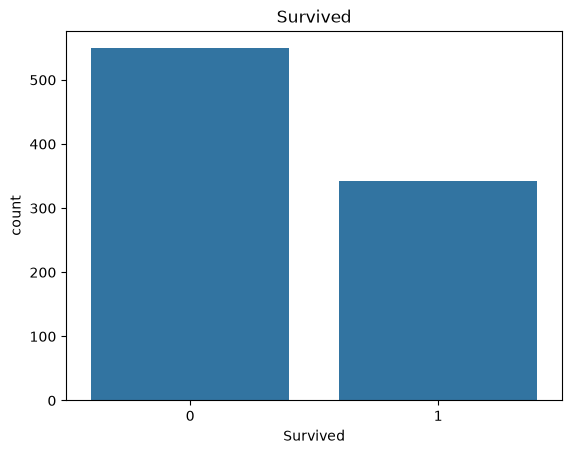

In [20]:
print(train[target].value_counts())

sns.countplot(data=train, x=target)
plt.title(target)
plt.show()

In [21]:
train[target].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Target имеет умеренный дисбаланс классов: 61.6% объектов относятся к классу 0 и 38.4% — к классу 1.  
Выраженного дисбаланса, требующего обязательного применения методов балансировки, не наблюдается.

### Анализ числовых признаков

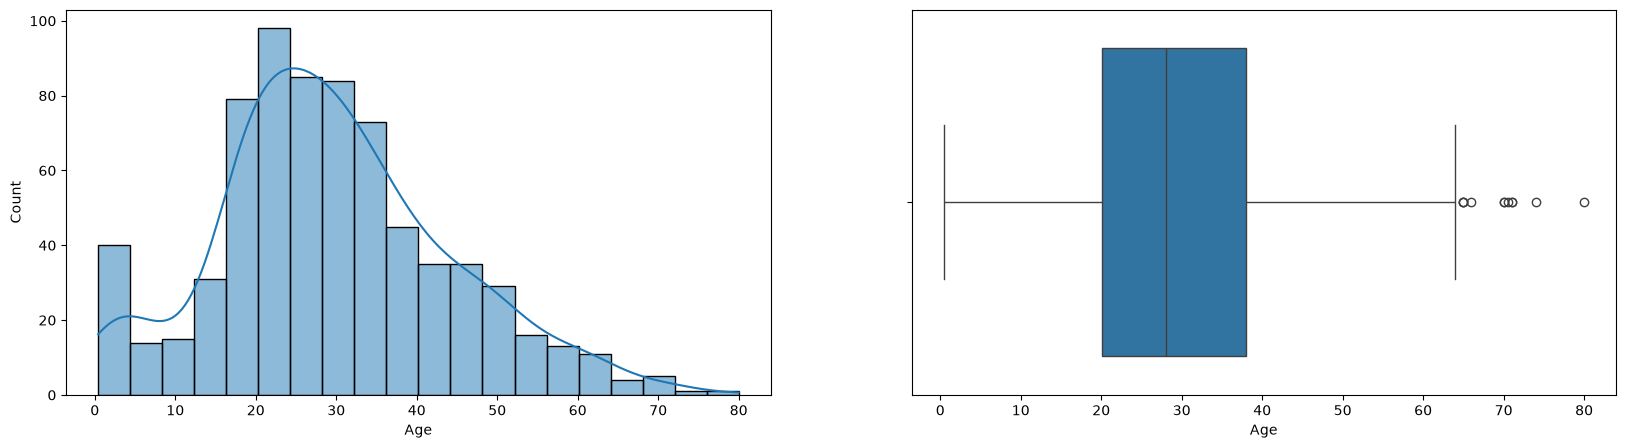

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


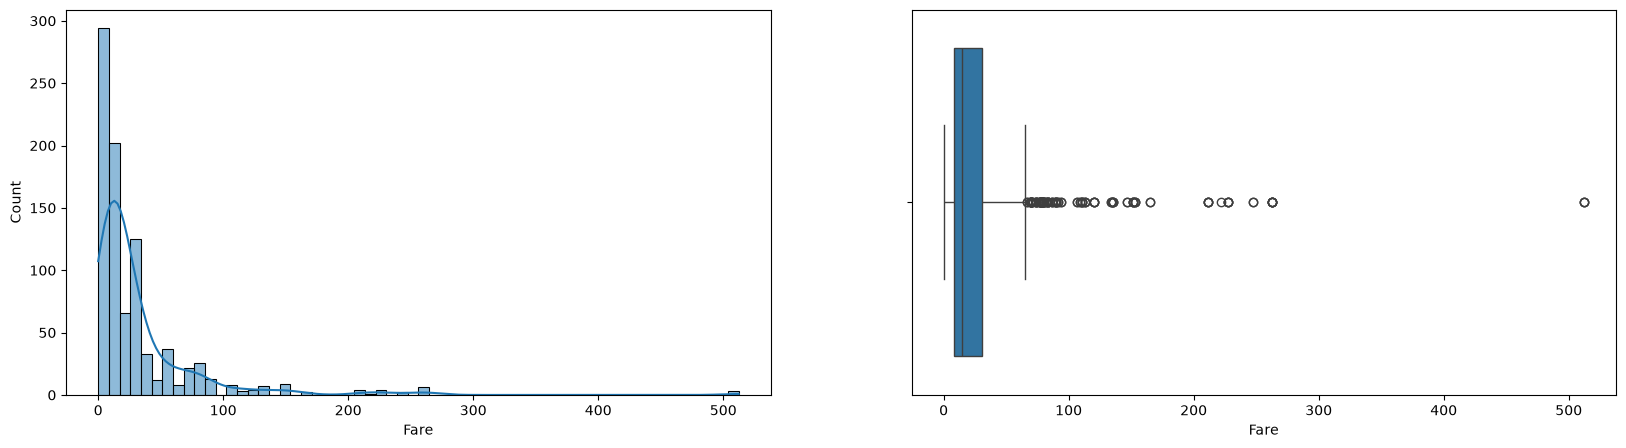

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


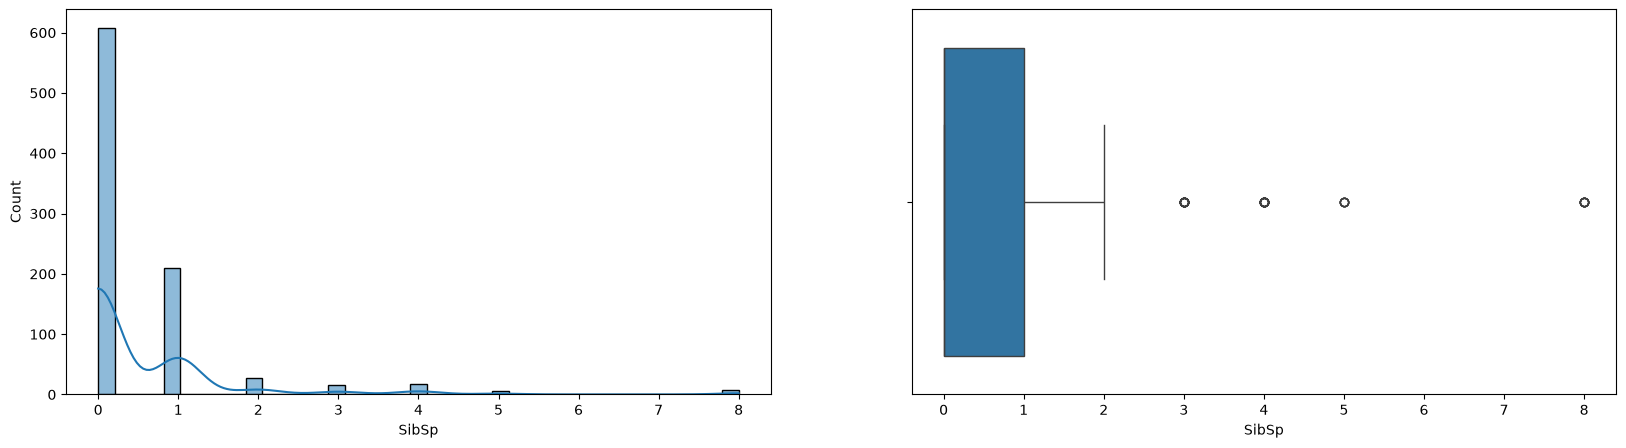

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64


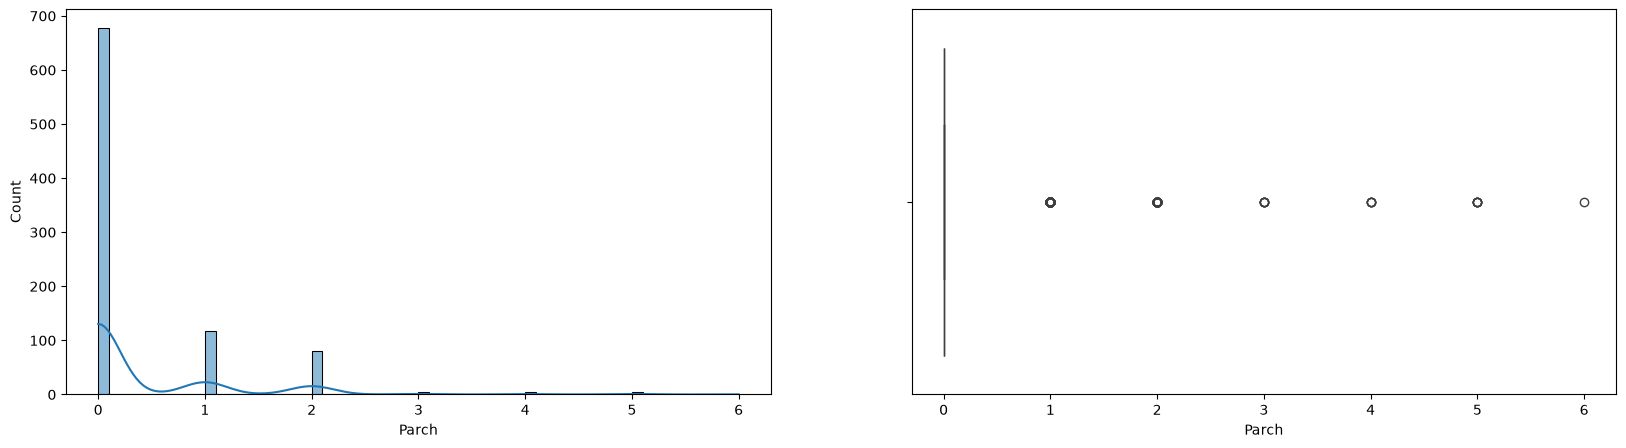

count    891.000000
mean       0.381594
std        0.806057
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        6.000000
Name: Parch, dtype: float64


In [23]:
def analysis_of_numerical_features(col):
    
    plt.figure(figsize=(20, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(
        data=train, 
        x=col, 
        kde=True)

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=train, 
        x=col); 
    plt.show()

    print(train[col].describe())

for feature in num_features:
    analysis_of_numerical_features(feature)


| **Признак** | **Тип** | **Асимметрия** | **Выбросы** |
|---|---|---|---|
| **Age** | Числовой неперерывный | Умеренная правосторонняя асимметрия | Наблюдаются небольшое количество редких значений, не похоже на выбросы |
| **Fare** | Числовой неперерывный | Сильная правосторонняя асимметрия | Наблюдаются множество редких значений, не похоже на выбросы |
| **Sex** | Числовой дискретный | Сильная правосторонняя асимметрия | Наблюдаются небольшое количество редких значений, не похоже на выбросы |
| **Embarked** | Числовой дискретный | Сильная правосторонняя асимметрия | Наблюдаются небольшое количество редких значений, не похоже на выбросы |

Пропущенные значения в признаке Age можно заполнить медианной, так как среднее значение смещено из-за небольшого количества больших значений

## Анализ категориальных признаков

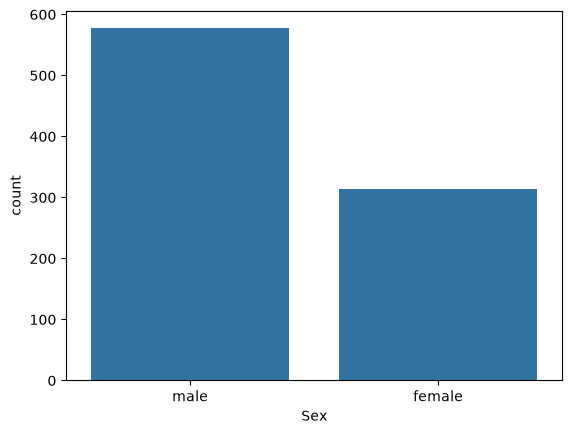

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64


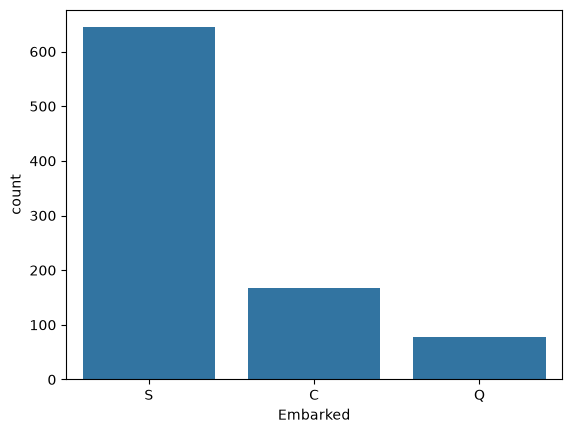

Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64


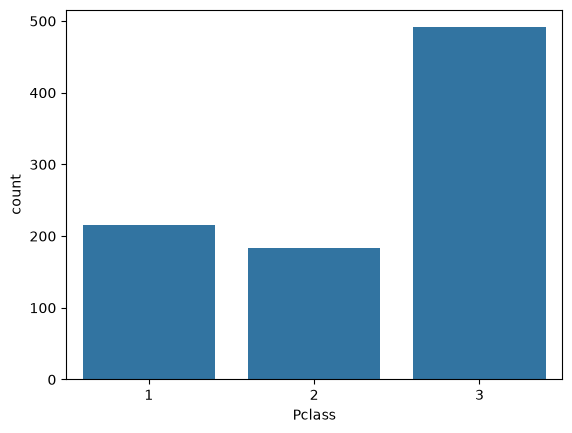

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64


In [ ]:
def analysis_of_categorical_features(col):
    
    plt.figure()
    sns.countplot(
        data=train, 
        x=col)
    plt.show()

    print(train[col].value_counts(normalize=True))
 
for feature in cat_features:
    analysis_of_categorical_features(feature)

**Sex**  
Переменная имеет 2 категории  
 
 
**Embarked**  
Переменная имеет 3 категории  


  



| Параметр | Кол-во категорий | Дисбаланс |
| --- | --- | --- |
|**Sex**  | 2 | Умеренный дисбаланс: male (64.7%) |
|**Embarked** | 3 | Выраженный дисбаланс: S (72,2 %) |
| **Pclass** | 3  | Умеренный дисбаланс: 3 (55,1 %) |

## Анализ специальных признаков

На текущем этапе работы анализ специальных признаков, потенциально несущих полезную информацию, опускается

## Связь между числовыми признаками

**Корреляционная матрица для числовых признаков**

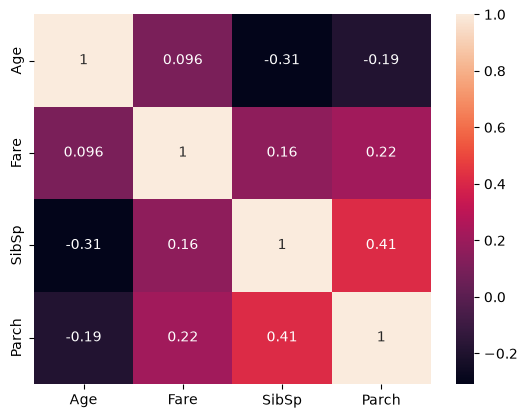

In [26]:
plt.figure()
sns.heatmap(
    train[num_features].corr(),
    annot=True
)
plt.show()

Корреляционная матрица показывает, что между признаками отсутствует сильная линейная зависисомсть  
Наибольшая корреляция наблюдается между признаками **SibSp** и **Parch** - **0.41**  


## Связь между категориальными признаками

In [29]:
for feature_1, feature_2 in combinations(cat_features, 2):

    table = pd.crosstab(
        train[feature_1],
        train[feature_2]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    print(f'\n{feature_1} × {feature_2}')
    print(f'χ² = {chi2:.3f}')
    print(f'p-value = {p_value:.4f}')
    print(f"Cramér's V = {cramers_v:.3f}")

    display(table)


Sex × Embarked
χ² = 13.356
p-value = 0.0013
Cramér's V = 0.123


Embarked,C,Q,S
Sex,,,
female,73,36,203
male,95,41,441



Sex × Pclass
χ² = 16.971
p-value = 0.0002
Cramér's V = 0.138


Pclass,1,2,3
Sex,,,
female,94,76,144
male,122,108,347



Embarked × Pclass
χ² = 123.752
p-value = 0.0000
Cramér's V = 0.264


Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


| | **Sex** | **Pclass** | **Embarked** |
|--|--|--|--|
|**Sex**|-|-|-|
|**Pclass**|мужчин и женщин больше всего в третьем классе, при этом в 3ем классе мужчин больше более чем в 2 раза|-|-|
|**Embarked**|В порту S мужчин в 2 раза бльше, чем женщин, в остальных портах доли примерно равны|в порту Q подавляющее большенство пассажиров 3 класса, похожая ситуавця в порту S, наибольшая доля пассажиров первого класса наблюдается в порту C (около 50 %)|-|


## Связь числовых признаков и целевой переменной

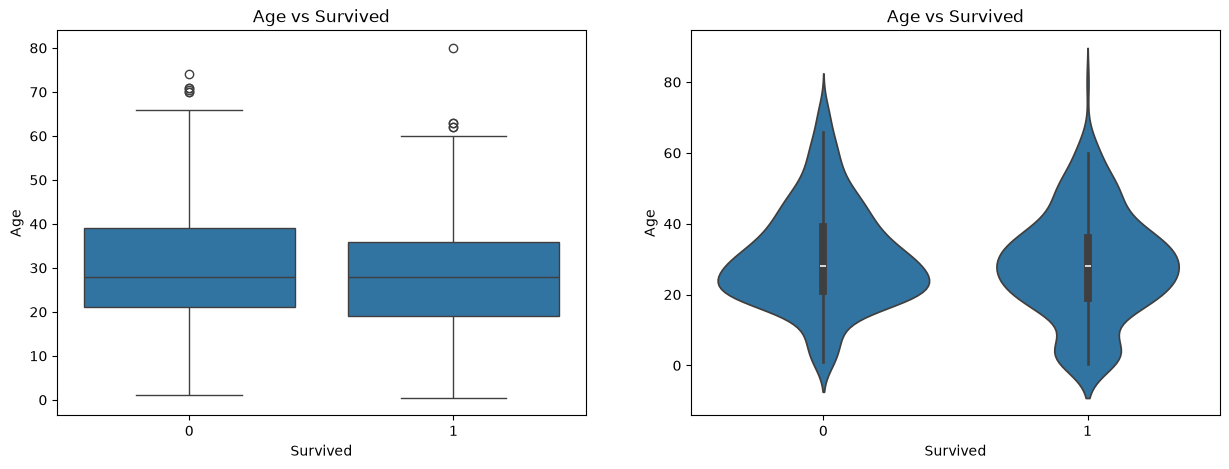

          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


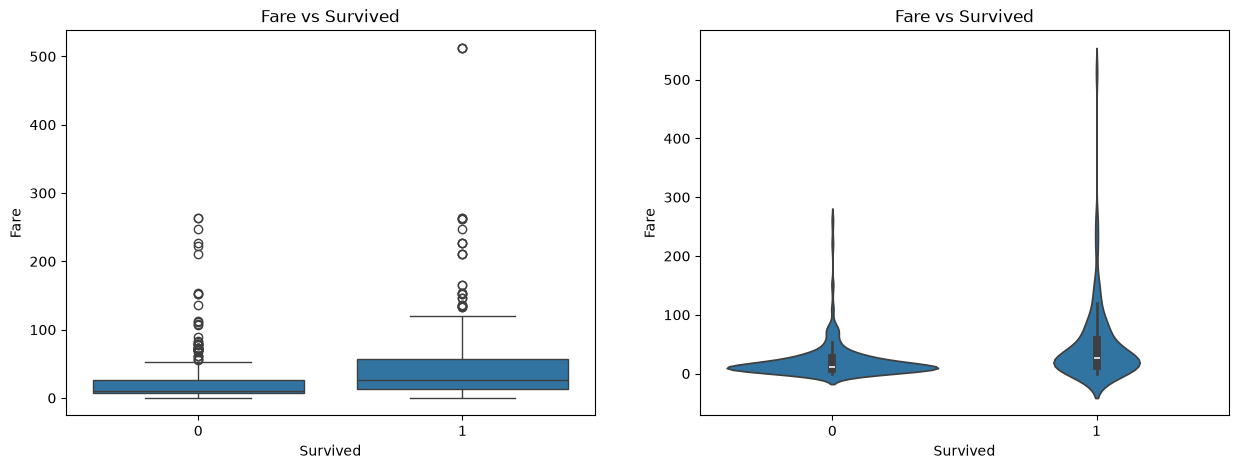

          count       mean        std  min      25%   50%   75%       max
Survived                                                                 
0         549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0  263.0000
1         342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0  512.3292


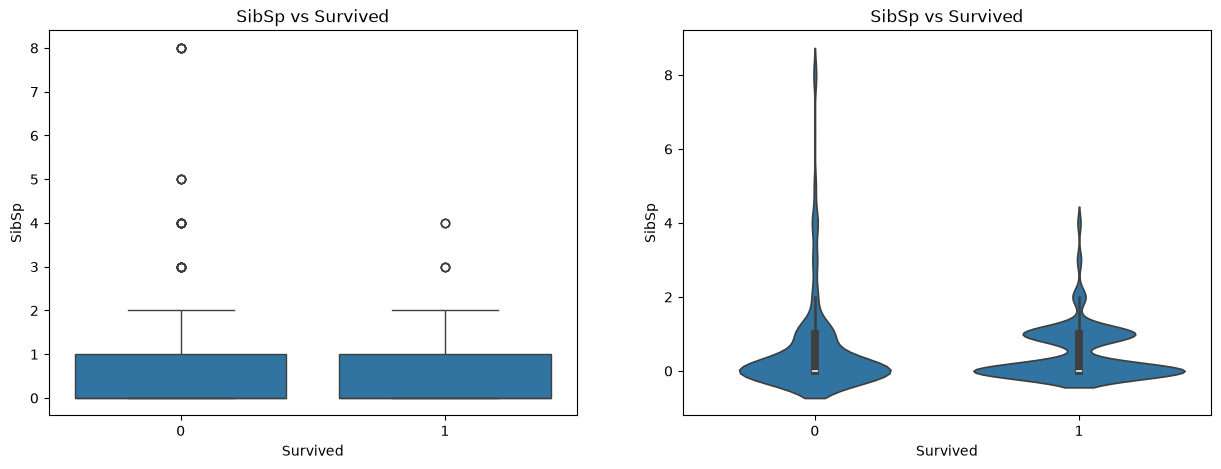

          count      mean       std  min  25%  50%  75%  max
Survived                                                    
0         549.0  0.553734  1.288399  0.0  0.0  0.0  1.0  8.0
1         342.0  0.473684  0.708688  0.0  0.0  0.0  1.0  4.0


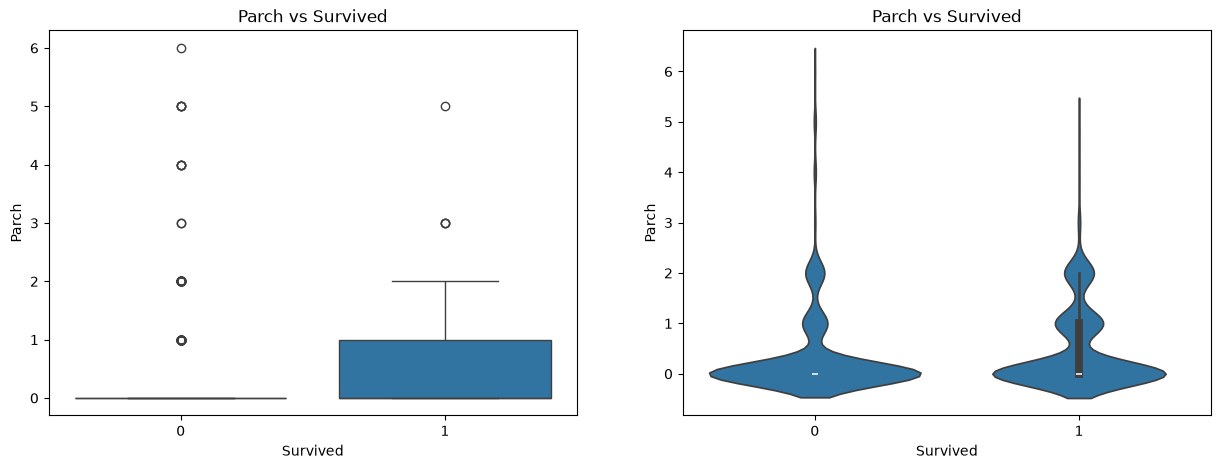

          count      mean       std  min  25%  50%  75%  max
Survived                                                    
0         549.0  0.329690  0.823166  0.0  0.0  0.0  0.0  6.0
1         342.0  0.464912  0.771712  0.0  0.0  0.0  1.0  5.0


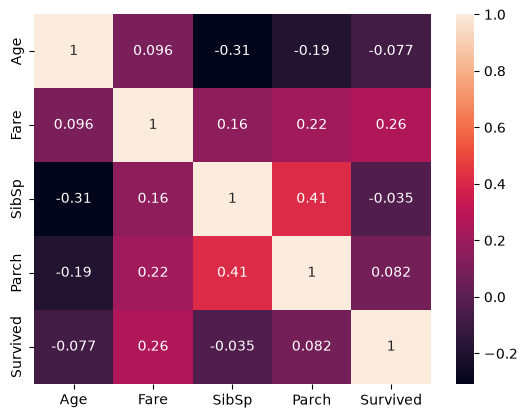

In [30]:
def num_features_target(col):

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    sns.boxplot(
        data=train,
        x=target,
        y=col
    )
    plt.title(f'{col} vs {target}')

    plt.subplot(1, 2, 2)
    sns.violinplot(
        data=train,
        x=target,
        y=col
    )
    
    plt.title(f'{col} vs {target}')
    plt.show()

    print(train.groupby(target)[col].describe())

for feature in num_features:
    num_features_target(feature)

plt.figure()
sns.heatmap(train[num_features + [target]].corr(),
            annot=True
)
plt.show()

**Age**  
Среднее значение признака Age для обоих групп примерно равны, для target = 1 среднее немного ниже  
Медианы совпадают    
Распределения схожи, значимых различий не наблюдается   
**Fare**  
Среднее признака Fare выше для 1 категории таргет    
Медианы также сильно отличаются    
Распределения признака Fare для групп таргета различны  
**SibSp**    
Среднее признака SibSp между категориями не значительно выше для 0 категории таргета    
Медианы равны    
Распределения признака SibSp для групп таргета похожи  
**Parch**    
Среднее признака Parch между категориями выше для 1 категории таргета    
Медианы равны   
Распределения признака Parch для групп различны  

Наибольшая линейная зависимость между числовыми признаками и таргетом проявляется у признака **Fare** - **0.26**  
Это модет говорить об отсутствии утечки данных

## Связь категориальных признаков и целевой переменной


Sex × Survived
χ² = 260.717
p-value = 0.0000
Cramér's V = 0.541


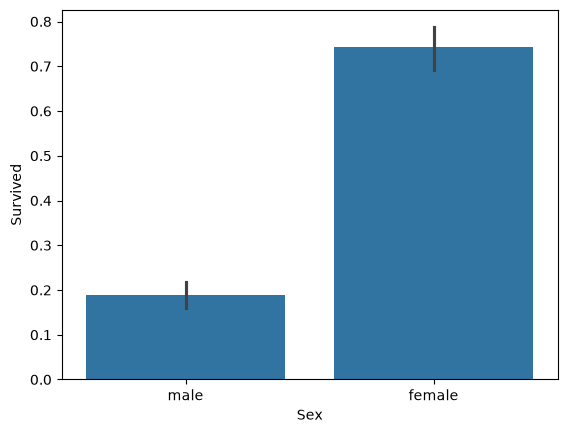

Survived,0,1
Sex,,
female,81,233
male,468,109



Embarked × Survived
χ² = 26.489
p-value = 0.0000
Cramér's V = 0.173


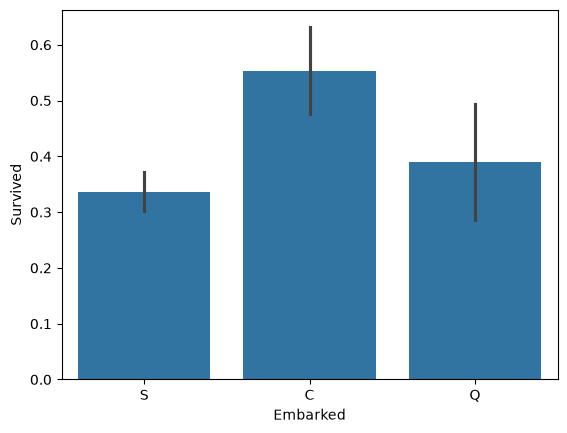

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217



Pclass × Survived
χ² = 102.889
p-value = 0.0000
Cramér's V = 0.340


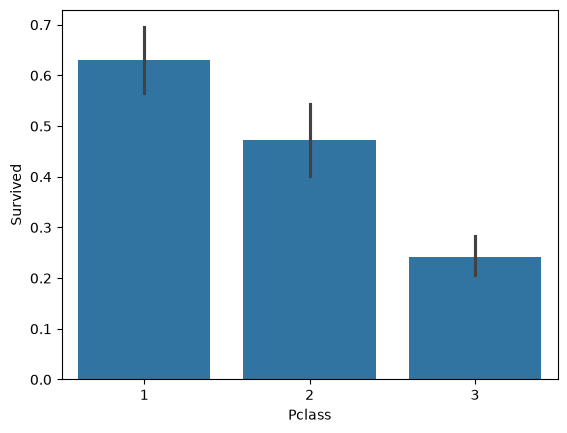

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [32]:
for feature in cat_features:

    table = pd.crosstab(
        train[feature],
        train[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    min_dim = min(table.shape) - 1

    cramers_v = np.sqrt(
        chi2 / (n * min_dim)
    )

    print(f'\n{feature} × {target}')

    print(f'χ² = {chi2:.3f}')
    print(f'p-value = {p_value:.4f}')
    print(f"Cramér's V = {cramers_v:.3f}")

    plt.figure()
    sns.barplot(
        data=train,
        x=feature,
        y=target
    )
    plt.show()



    display(table)

**Sex**  
Доля объектов с target = 1 в категории female гораздо выше, чем у male.  
Это указывает на сильную связь Sex и Target  

**Embarked**  
Доля объектов с target = 1 в категории С выше, чем у male.   
Это указывает на наличие связи между признаком Embarked и таргетом 

**Pclass**  
Наблюдается прямая связь меджу категориями призака Pclass и таргетом  
Видна иерархия между категориями